# 05 — Beam matching the equatorial maps to the TRIS beam

Applies stage 2's existing `smooth_to_target()` to Haslam and both ARCADE 2 bands, in the
**equatorial** frame produced by the coordinate fix (`notebooks/04_coordinate_frames`,
`src/moonrunes/frames.py`). The function is used as-is.

| quantity | value | source |
|---|---|---|
| target FWHM | 23.366° | TRIS H-plane, the Step 0.1 choice |
| Haslam native FWHM | 56′ = 0.9333° | `BEAMSIZE` in the FITS header |
| ARCADE 2 native FWHM | 12.0° | `beam_matching.arcade2_native_fwhm_deg` |

The extra kernel is added in quadrature, $\sqrt{23.366^2 - \mathrm{native}^2}$: 23.35° for
Haslam and 20.05° for ARCADE 2.

This notebook **does not regrid to nside 8**. That is the next step, and it waits until
the smoothing below has been confirmed.

In [16]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import frames
from moonrunes.stage2_beam_matching import smooth_to_target, extra_fwhm_deg, observed_mask

config = load_config(REPO / "configs" / "run_config.yaml")

TARGET_FWHM_DEG = 23.366
HASLAM_NATIVE_FWHM_DEG = 56 / 60
ARCADE2_NATIVE_FWHM_DEG = 12.0
WEIGHT_FLOOR = float(config.require("beam_matching.weight_floor"))   # 0.5
print(f"extra kernel: Haslam {extra_fwhm_deg(HASLAM_NATIVE_FWHM_DEG, TARGET_FWHM_DEG):.3f}°, "
      f"ARCADE 2 {extra_fwhm_deg(ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG):.3f}°; "
      f"weight floor {WEIGHT_FLOOR}")

extra kernel: Haslam 23.347°, ARCADE 2 20.049°; weight floor 0.5


---
## 1. Load the equatorial maps, and prove they are the equatorial ones

The coordinate fix does not write rotated files to disk. It is a pair of functions that
the raw Galactic FITS files go through. So "loading the reprojected maps" means reading
each file, checking that it declares Galactic, and rotating it with the same calls that
notebook 04 validated. Three checks then confirm the maps now in memory are the rotated
ones, not the originals:

* each rotated array differs from the raw read;
* Haslam's Cas A peak sits at its literature RA/Dec, which is only true after rotation;
* ARCADE 2 tracks the rotated Haslam sky (correlation ≈ 0.95, against ≈ −0.07 unrotated).

In [17]:
RAW, EQ = {}, {}
paths = {"Haslam 408 MHz":    config.resolve_path("paths.haslam_map_fits"),
         "ARCADE 2 3.15 GHz": config.resolve_path("paths.arcade2_map_3150"),
         "ARCADE 2 3.41 GHz": config.resolve_path("paths.arcade2_map_3410")}
for name, path in paths.items():
    declared = frames.declared_frame(path)["frame"]
    assert declared == "G", f"{name} declares {declared}, expected G"
    raw = hp.read_map(path)                               # RING, Galactic
    RAW[name] = raw
    if name.startswith("Haslam"):
        EQ[name] = frames.rotate_full_sky(raw, ("G", "C"))
    else:
        EQ[name], _, _ = frames.rotate_masked(raw, observed_mask(raw, "zeros"), ("G", "C"))
    print(f"{name:<18} declares {declared} -> rotated G->C; "
          f"pixels changed by the rotation: {100 * np.mean(EQ[name] != raw):.0f}%")

CAS_A = {"Cas A": (350.85, 58.815)}
for label, sky in (("equatorial map", EQ["Haslam 408 MHz"]), ("raw Galactic map", RAW["Haslam 408 MHz"])):
    r = frames.source_offsets_deg(sky, CAS_A, 5.0)["Cas A"]
    print(f"Cas A in the {label:<17}: peak {r['peak_k']:6.0f} K, {r['offset_deg']:.2f}° from its literature RA/Dec")

haslam_16 = hp.ud_grade(EQ["Haslam 408 MHz"], 16)
for name in ("ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz"):
    m = EQ[name] != hp.UNSEEN
    print(f"{name}: correlation with equatorial Haslam {np.corrcoef(EQ[name][m], haslam_16[m])[0, 1]:.3f}")

Haslam 408 MHz     declares G -> rotated G->C; pixels changed by the rotation: 100%
ARCADE 2 3.15 GHz  declares G -> rotated G->C; pixels changed by the rotation: 100%
ARCADE 2 3.41 GHz  declares G -> rotated G->C; pixels changed by the rotation: 100%
Cas A in the equatorial map   : peak   4863 K, 0.11° from its literature RA/Dec
Cas A in the raw Galactic map : peak     29 K, 4.70° from its literature RA/Dec
ARCADE 2 3.15 GHz: correlation with equatorial Haslam 0.954
ARCADE 2 3.41 GHz: correlation with equatorial Haslam 0.954


---
## 2. Smooth

Haslam is full sky and gets no `weight_mask`. Each ARCADE 2 map gets
`weight_mask = (map != hp.UNSEEN)`, built from the map **as it is now**, after rotation. The
rotated maps mark unobserved sky with `hp.UNSEEN`, not the zeros the files use, so the
mask is taken from the current state.

In [18]:
SMOOTH, MASK_BEFORE = {}, {}
SMOOTH["Haslam 408 MHz"] = smooth_to_target(EQ["Haslam 408 MHz"], HASLAM_NATIVE_FWHM_DEG,
                                            TARGET_FWHM_DEG)
for name in ("ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz"):
    MASK_BEFORE[name] = EQ[name] != hp.UNSEEN
    SMOOTH[name] = smooth_to_target(EQ[name], ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG,
                                    weight_mask=MASK_BEFORE[name], weight_floor=WEIGHT_FLOOR)

---
## 3. Sanity checks

**UNSEEN counts.** The `w < 0.5` re-mask should widen the mask a little at the ring's edges.
If the UNSEEN count shrinks, or the observed set shrinks to nothing, the run stops here.

**Did the ring move?** The before/after mollviews are the visual test. Three numbers back
them up: the centroid shift of the observed region, whether every surviving pixel was
observed before smoothing, and the mean temperature over the pixels that survive.
Smoothing that renormalises by the weight should leave that mean nearly unchanged.

In [19]:
def centroid(mask, nside):
    v = np.array(hp.pix2vec(nside, np.flatnonzero(mask))).sum(axis=1)
    return v / np.linalg.norm(v)

kernel = np.radians(extra_fwhm_deg(ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG))
CHURN = {}
print(f"{'map':<18}{'UNSEEN before':>14}{'after':>8}{'change':>8}   observed: "
      f"{'kept':>5}{'dropped':>9}{'added':>7}{'centroid shift':>16}")
for name in ("ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz"):
    before, after = MASK_BEFORE[name], SMOOTH[name] != hp.UNSEEN
    n_before, n_after = int((~before).sum()), int((~after).sum())
    kept, dropped, added = before & after, before & ~after, after & ~before
    CHURN[name] = dict(kept=kept, dropped=dropped, added=added)
    shift = np.degrees(np.arccos(np.clip(centroid(before, 16) @ centroid(after, 16), -1, 1)))
    print(f"{name:<18}{n_before:14d}{n_after:8d}{n_after - n_before:+8d}             "
          f"{int(kept.sum()):5d}{int(dropped.sum()):9d}{int(added.sum()):7d}{shift:15.2f}°")
    if n_after < n_before or after.sum() == 0:
        raise RuntimeError(f"{name}: mask shrank or vanished after smoothing -- stop, do not regrid")

    weight = hp.smoothing(before.astype(float), fwhm=kernel, iter=3)
    _, dec_drop = hp.pix2ang(16, np.flatnonzero(dropped), lonlat=True)
    _, dec_obs = hp.pix2ang(16, np.flatnonzero(before), lonlat=True)
    print(f"{'':<18}smoothed weight: max {weight[before].max():.2f} anywhere in the footprint, "
          f"median {np.median(weight[before]):.2f}")
    print(f"{'':<18}mean T over the {int(kept.sum())} kept pixels {EQ[name][kept].mean():.4f} -> "
          f"{SMOOTH[name][kept].mean():.4f} K; std {1e3 * EQ[name][kept].std():.0f} -> "
          f"{1e3 * SMOOTH[name][kept].std():.0f} mK")
    print(f"{'':<18}dropped pixels: {int(np.sum(dec_drop > 55))} at Dec > +55° (northern arc), "
          f"{int(np.sum(dec_drop < 10))} at Dec < +10° (southern tip, the plane crossing), "
          f"{int(np.sum((dec_drop >= 10) & (dec_drop <= 55)))} along the arms' edges")
    print(f"{'':<18}added pixels (never observed): {int(added.sum())}, smoothed weight "
          f"{weight[added].min():.2f}–{weight[added].max():.2f}, each one 3.7° pixel from data\n")

h0, h1 = EQ["Haslam 408 MHz"], SMOOTH["Haslam 408 MHz"]
print(f"Haslam: UNSEEN {int((h0 == hp.UNSEEN).sum())} -> {int((h1 == hp.UNSEEN).sum())}; "
      f"mean {h0.mean():.3f} -> {h1.mean():.3f} K (a smoothing keeps the monopole); "
      f"max {h0.max():.0f} -> {h1.max():.1f} K; min {h0.min():.1f} -> {h1.min():.1f} K")
peak = np.argmax(h1)
print(f"Haslam smoothed maximum at RA {hp.pix2ang(512, peak, lonlat=True)[0]:.1f}°, "
      f"Dec {hp.pix2ang(512, peak, lonlat=True)[1]:+.1f}° (the Galactic-centre region)")

map                UNSEEN before   after  change   observed:  kept  dropped  added  centroid shift
ARCADE 2 3.15 GHz           2852    2898     +46               170       50      4           1.14°
                  smoothed weight: max 0.85 anywhere in the footprint, median 0.61
                  mean T over the 170 kept pixels 2.8775 -> 2.8757 K; std 84 -> 64 mK
                  dropped pixels: 16 at Dec > +55° (northern arc), 24 at Dec < +10° (southern tip, the plane crossing), 10 along the arms' edges
                  added pixels (never observed): 4, smoothed weight 0.50–0.57, each one 3.7° pixel from data

ARCADE 2 3.41 GHz           2838    2874     +36               193       41      5           0.94°
                  smoothed weight: max 0.85 anywhere in the footprint, median 0.63
                  mean T over the 193 kept pixels 2.8424 -> 2.8414 K; std 72 -> 53 mK
                  dropped pixels: 16 at Dec > +55° (northern arc), 15 at Dec < +10° (southern tip, the plane c

---
## 4. Before and after

Everything is drawn in equatorial coordinates (`coord="C"`, so no further rotation happens
at plot time), with the same colour range before and after for each map. Haslam is shown
as log₁₀ T because its dynamic range runs from 11 K to 4800 K.

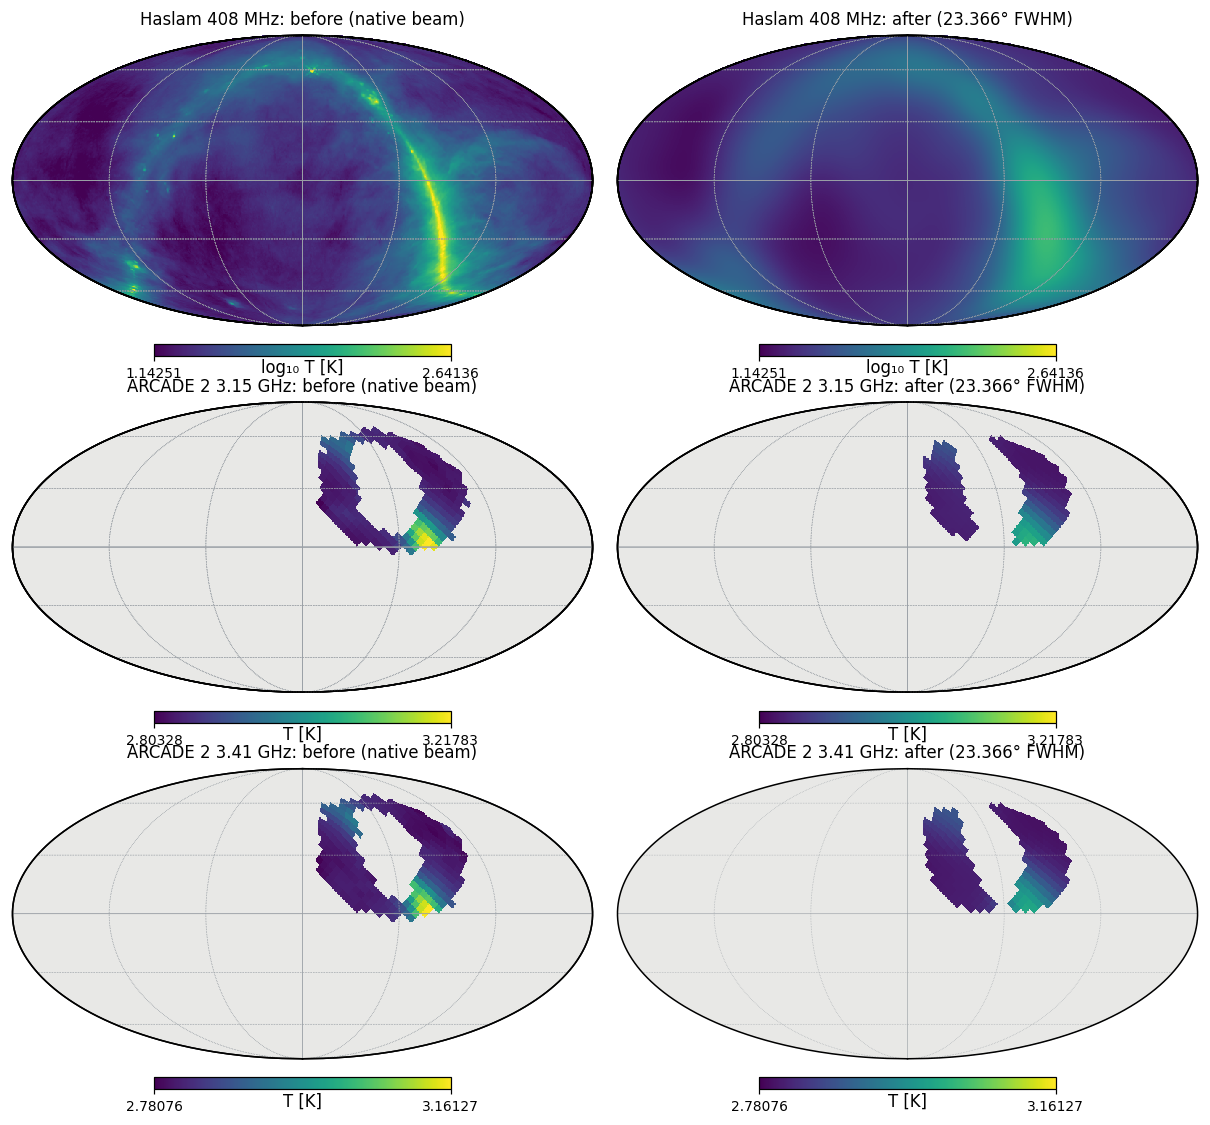

In [20]:
fig = plt.figure(figsize=(11, 10))
panel = 1
for name in ("Haslam 408 MHz", "ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz"):
    before, after = EQ[name], SMOOTH[name]
    if name.startswith("Haslam"):
        before, after = np.log10(before), np.log10(after)
        lo, hi, unit = np.percentile(before, [1, 99.9]), None, "log₁₀ T [K]"
        lo, hi = lo
    else:
        vals = before[before != hp.UNSEEN]
        lo, hi, unit = vals.min(), vals.max(), "T [K]"
    for label, m in (("before (native beam)", before), ("after (23.366° FWHM)", after)):
        hp.mollview(m, coord="C", sub=(3, 2, panel), fig=fig.number, min=lo, max=hi,
                    title=f"{name}: {label}", unit=unit, cmap="viridis",
                    badcolor="#e8e8e6", notext=True)
        hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
        panel += 1
plt.show()

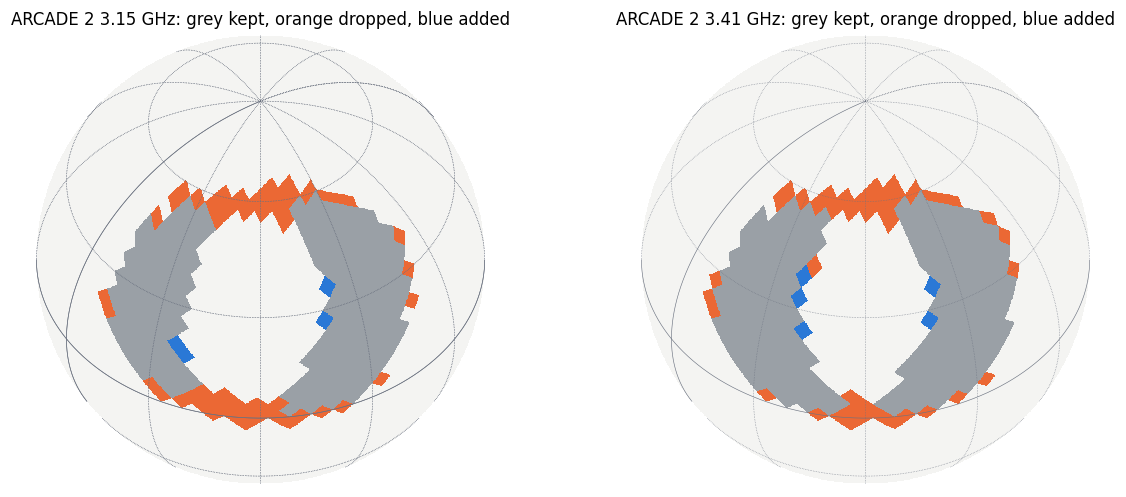

In [21]:
# Where the footprint changed: kept / dropped by the w < 0.5 re-mask / added by it.
from matplotlib.colors import ListedColormap
CATS = ListedColormap(["#9aa0a6", "#eb6834", "#2a78d6"])     # kept, dropped, added
CATS.set_bad("#f4f4f2"); CATS.set_under("white")
fig = plt.figure(figsize=(11, 4.2))
for column, name in enumerate(("ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz")):
    c = CHURN[name]
    m = np.full(3072, hp.UNSEEN)
    m[c["kept"]], m[c["dropped"]], m[c["added"]] = 0, 1, 2
    hp.orthview(m, coord="C", rot=[300, 45], half_sky=True, sub=(1, 2, column + 1),
                fig=fig.number, cmap=CATS, min=-0.5, max=2.5, cbar=False, notext=True,
                title=f"{name}: grey kept, orange dropped, blue added")
    hp.graticule(dpar=30, dmer=30, color="#6b7280", lw=0.4)
plt.show()

---
## Verdict: stop before regridding

**The step-3 checks pass.**

* UNSEEN grows by 46 pixels (3.15 GHz) and 36 pixels (3.41 GHz), so the mask widens rather
  than shrinking.
* The mean temperature over the kept pixels changes by less than 2 mK.
* Haslam stays full sky with its mean unchanged, and its smoothed peak is the
  Galactic-centre region.

**The visual check fails the "still recognisably a ring" test.** The ring has not moved:
what survives sits where it was, and the centroid moves by about 1°, a third of a pixel.
But the ring is cut at its **two narrow junctions**, and in both bands it breaks into two
separate arcs, east and west.

* **The northern arc** (Dec ≳ +55°): 16 pixels dropped in each band.
* **The southern tip** (Dec ≲ +10°), where the two arms meet: 24 and 15 pixels dropped.
  This is where the ring crosses the Galactic plane, and it holds the brightest ARCADE 2
  emission. About a quarter of the |b| < 10° pixels are lost (12 of 43 and 11 of 46),
  including 2 of the 10 brightest pixels in each band.
* **Why.** At both junctions the footprint is only one or two nside-16 pixels wide, narrow
  next to the 20° extra kernel. The smoothed weight never gets above about 0.85 anywhere
  in the footprint, and at the junctions it stays below the 0.5 floor.
* **Not caused by the rotation.** Smoothing the same maps in their native Galactic frame
  loses about the same number of pixels (168 of 220 and 195 of 232 survive).

**The net UNSEEN count hides churn.** About 50 and 41 observed pixels are dropped, and 4
and 5 pixels that were **never observed** are added. The added ones are one pixel from
real data, with weights of 0.50–0.57. That is what zero-and-reweight does by design, but it
means those values are extrapolations. Section 5 removes them from the final ARCADE 2 mask.

**Decision needed before regridding.** Either accept the two-arc ARCADE 2 footprint, or
change the approach. The options are a lower `weight_floor`, or accepting a smaller
effective target for ARCADE 2. Both are pipeline decisions, and `smooth_to_target` was
deliberately not changed here.

---
## 5. Usable overlap at nside 8, before regridding

`smooth_to_target()` and the 0.5 weight floor stay as they are. This section changes only
what happens after them, and measures how many nside 8 pixels all four maps can share.

**The final ARCADE 2 mask** is now

$$\text{observed before smoothing} \;\land\; w_\text{smoothed} \ge \text{floor}$$

This keeps the edge-dropping of the weight floor and removes the extrapolated pixels, the
ones that were never observed but came back above the floor. "Observed before smoothing"
is the equatorial mask from section 2 (`MASK_BEFORE`).

**The TRIS coverage** comes from the stage 1 product,
`outputs/stage1_nside8/tris_maps_tris_stage1_nside8.npz`. Its `band_mask` is the set of
nside 8 pixels the ring solved for. Both frequencies share one pixel set, which stage 1
enforces.

**An nside 16 ARCADE 2 mask on the nside 8 grid.** Each nside 8 pixel holds four nside 16
children. "ARCADE 2 has data here" is not defined until you say how many of the four must
be in the final mask. That is the same decision the regrid will face when it fills
partially covered pixels. So all three readings are counted:

* **all**: 4 of 4 children observed. The nside 8 value would be a clean average of
  observed sky.
* **majority**: at least 2 of 4.
* **any**: at least 1 of 4. The nside 8 value would rest on a single 3.7° child.

In [22]:
FLOORS = (0.5, 0.4)
ARCADE_NAMES = ("ARCADE 2 3.15 GHz", "ARCADE 2 3.41 GHz")
FINAL, SMOOTH_AT = {}, {}
print(f"{'map':<18}{'floor':>6}{'w ≥ floor':>11}{'final':>7}{'removed (never observed)':>26}")
for name in ARCADE_NAMES:
    for floor in FLOORS:
        smoothed = (SMOOTH[name] if floor == WEIGHT_FLOOR else
                    smooth_to_target(EQ[name], ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG,
                                     weight_mask=MASK_BEFORE[name], weight_floor=floor))
        above = smoothed != hp.UNSEEN
        final = above & MASK_BEFORE[name]
        SMOOTH_AT[name, floor] = np.where(final, smoothed, hp.UNSEEN)
        FINAL[name, floor] = final
        print(f"{name:<18}{floor:6.1f}{int(above.sum()):11d}{int(final.sum()):7d}"
              f"{int((above & ~MASK_BEFORE[name]).sum()):26d}")

map                floor  w ≥ floor  final  removed (never observed)
ARCADE 2 3.15 GHz    0.5        174    170                         4
ARCADE 2 3.15 GHz    0.4        251    211                        40
ARCADE 2 3.41 GHz    0.5        198    193                         5
ARCADE 2 3.41 GHz    0.4        270    230                        40


In [23]:
TRIS_PATH = REPO / "outputs" / "stage1" / "tris_maps_tris_haslam_v0.npz"
tris_npz = np.load(TRIS_PATH)
NSIDE_OUT = int(tris_npz["nside"])
assert NSIDE_OUT == 16
TRIS_BAND = tris_npz["band_mask"].astype(bool)
for row, freq in enumerate(tris_npz["freq_mhz"]):
    finite = np.isfinite(tris_npz["sky_full_k"][row])
    assert np.array_equal(finite, TRIS_BAND), f"{freq:.0f} MHz map and band_mask disagree"
ra_b, dec_b = hp.pix2ang(NSIDE_OUT, np.flatnonzero(TRIS_BAND), lonlat=True)
tightened = (tris_npz["sky_sigma_k"] / tris_npz["prior_sigma_k"]) < 0.95
print(f"TRIS: {TRIS_PATH.relative_to(REPO)}")
print(f"  nside {NSIDE_OUT}, {int(TRIS_BAND.sum())} of {hp.nside2npix(NSIDE_OUT)} pixels carry a "
      f"solved value at both 600 and 820 MHz (the same set)")
print(f"  Dec {dec_b.min():+.1f}° to {dec_b.max():+.1f}° at pixel centres, all RA "
      f"({ra_b.min():.0f}–{ra_b.max():.0f}°)")
print(f"  of those, the data tightened σ by >5% on {tightened[0].sum()} (600 MHz) and "
      f"{tightened[1].sum()} (820 MHz); the rest are close to the prior")

TRIS: outputs/stage1/tris_maps_tris_haslam_v0.npz
  nside 16, 1272 of 3072 pixels carry a solved value at both 600 and 820 MHz (the same set)
  Dec +9.6° to +75.3° at pixel centres, all RA (0–357°)
  of those, the data tightened σ by >5% on 23 (600 MHz) and 7 (820 MHz); the rest are close to the prior


In [24]:
def parent8(pix16):
    # A child's NESTED index divided by 4 is its parent's NESTED index.
    return hp.nest2ring(16, hp.ring2nest(16, pix16) // 4)

def child_fraction(mask16):
    # Fraction of each nside 8 pixel's 4 children that are in the mask.
    return hp.ud_grade(mask16.astype(float), 16, order_in="RING", order_out="RING")

RULES = {"all": lambda f: f == 1.0, "majority": lambda f: f >= 0.5, "any": lambda f: f > 0.0}
OVERLAP = {}
print(f"pixels at nside 8 where TRIS 600, TRIS 820, ARCADE 2 3.15 and 3.41 ALL have data")
print(f"{'floor':>6}" + "".join(f"{r:>10}" for r in RULES) + "   (ARCADE 2 child rule)")
for floor in FLOORS:
    fracs = [child_fraction(FINAL[name, floor]) for name in ARCADE_NAMES]
    counts = []
    for rule, ok in RULES.items():
        OVERLAP[floor, rule] = TRIS_BAND & ok(fracs[0]) & ok(fracs[1])
        counts.append(int(OVERLAP[floor, rule].sum()))
    print(f"{floor:6.1f}" + "".join(f"{c:10d}" for c in counts))

print("\nARCADE 2 nside 16 pixels inside the TRIS strip, floor 0.5")
for name in ARCADE_NAMES:
    above = SMOOTH[name] != hp.UNSEEN
    final = FINAL[name, WEIGHT_FLOOR]
    dropped = MASK_BEFORE[name] & ~above
    inside = lambda m: int(TRIS_BAND[parent8(np.flatnonzero(m))].sum())
    print(f"  {name}: w ≥ 0.5 {inside(above)}/{int(above.sum())};  final mask "
          f"{inside(final)}/{int(final.sum())};  dropped by the floor, but inside the "
          f"strip: {inside(dropped)}/{int(dropped.sum())}")

pixels at nside 8 where TRIS 600, TRIS 820, ARCADE 2 3.15 and 3.41 ALL have data
 floor       all  majority       any   (ARCADE 2 child rule)
   0.5       153       153       153
   0.4       172       172       172

ARCADE 2 nside 16 pixels inside the TRIS strip, floor 0.5
  ARCADE 2 3.15 GHz: w ≥ 0.5 141/174;  final mask 138/170;  dropped by the floor, but inside the strip: 48/50
  ARCADE 2 3.41 GHz: w ≥ 0.5 165/198;  final mask 161/193;  dropped by the floor, but inside the strip: 40/41


The map below uses floor 0.5. Grey is the TRIS strip. The three shades inside it show how
many of the ARCADE 2 child rules count a pixel as covered by both bands: all three
rules (darkest), only majority and any, or only any.

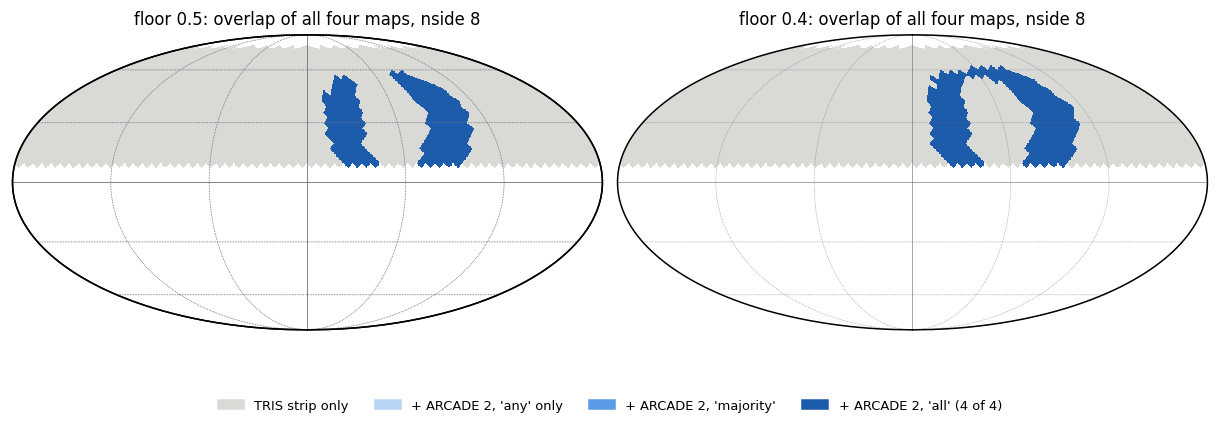

In [25]:
from matplotlib.colors import ListedColormap
LEVELS = ListedColormap(["#d9d9d6", "#b8d4f4", "#5b9be6", "#1c5cab"])
LEVELS.set_bad("white"); LEVELS.set_under("white")

fig = plt.figure(figsize=(11, 4.4))
for column, floor in enumerate(FLOORS):
    m = np.full(hp.nside2npix(16), hp.UNSEEN)
    m[TRIS_BAND] = 0
    m[OVERLAP[floor, "any"]] = 1
    m[OVERLAP[floor, "majority"]] = 2
    m[OVERLAP[floor, "all"]] = 3
    hp.mollview(m, coord="C", sub=(1, 2, column + 1), fig=fig.number, cmap=LEVELS,
                min=-0.5, max=3.5, cbar=False, notext=True,
                title=f"floor {floor}: overlap of all four maps, nside 8")
    hp.graticule(dpar=30, dmer=60, color="#6b7280", lw=0.4)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in LEVELS.colors]
fig.legend(handles, ["TRIS strip only", "+ ARCADE 2, 'any' only",
                     "+ ARCADE 2, 'majority'", "+ ARCADE 2, 'all' (4 of 4)"],
           loc="lower center", ncol=4, frameon=False, fontsize=8.5)
plt.show()

**Reading the numbers.** The four-way overlap is set by ARCADE 2, not by TRIS. The TRIS strip
covers almost the whole northern sky above +5°, and nearly every surviving ARCADE 2 pixel
falls inside it. The pixels the floor dropped would mostly have landed inside the strip
too. So the floor costs overlap directly.

At floor 0.4 the ARCADE 2 footprint grows, but the numbers above show where the growth
comes from. About 40 of the extra pixels per band pass the floor without ever having been
observed, and the final mask removes them. That leaves a modest gain in real overlap.

Which child rule to use is the same decision the regrid has to make for partially
covered nside 8 pixels, so it should be settled there, once, and used for both.